## We'll use AdaBoostClassifier and a decision stump as the weak learner, then inspect what the model is actually doing.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [10]:
# Load the dataset
data = load_breast_cancer()

X = data.data
y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [11]:
# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [40]:
# Create the weak learner
base_model = DecisionTreeClassifier(max_depth=1, random_state=42)

In [41]:
#  Create AdaBoost
ada = AdaBoostClassifier(estimator=base_model, n_estimators=50, learning_rate=1.0, random_state=42)

In [42]:
# Train the AdaBoost
ada.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42),
                   random_state=42)

## Conceptually:
```
X_train, y_train
       ↓
Initialize sample weights
       ↓
Train Tree 1
       ↓
Evaluate mistakes
       ↓
Update sample weights
       ↓
Train Tree 2
       ↓
Evaluate mistakes
       ↓
Update sample weights
       ↓
...
       ↓
Train Tree 50

In [43]:
# Make predictions
y_pred = ada.predict(X_test)

In [44]:
# Evaluate the model
accuracy = accuracy_score(y_test,y_pred)

print('Accuracy', accuracy)

Accuracy 0.956140350877193


In [45]:
# Print Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [46]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[38  4]
 [ 1 71]]


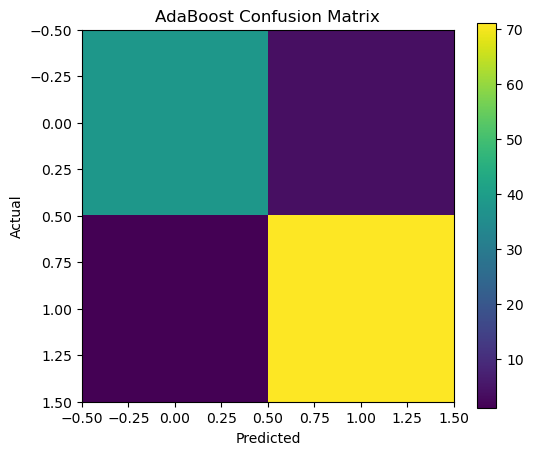

In [47]:
# Let's visualize it
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("AdaBoost Confusion Matrix")

plt.colorbar()

plt.show()

In [48]:
# Now, inspect the estimators
print(len(ada.estimators_))

50


In [49]:
# Inspect each tree's importance
ada.estimator_weights_

array([2.48490665, 1.74396881, 1.80718225, 1.28495082, 0.97874934,
       1.35521217, 1.16692674, 1.09069352, 0.99154396, 0.90092444,
       0.90184652, 0.98501919, 0.86557179, 1.01864   , 0.93051689,
       0.95231468, 0.72907064, 0.71660375, 0.40009773, 0.89115153,
       0.55852552, 0.77724201, 0.72514028, 0.90220518, 1.04971263,
       0.67871304, 0.58507121, 0.84660992, 0.7315246 , 0.93698378,
       0.67532169, 0.68123656, 0.8386741 , 0.60228062, 0.67780748,
       0.59895343, 0.52496287, 0.62612329, 0.67530747, 0.66511821,
       0.7202675 , 0.85017877, 0.62379326, 0.33939285, 0.54112656,
       0.38860115, 0.41353448, 0.57944664, 0.53211487, 0.60195494])

In [50]:
# See the estimator errors
print(ada.estimator_errors_)

[0.07692308 0.14880952 0.14097902 0.21670866 0.27314001 0.20501955
 0.23741094 0.25148771 0.27060722 0.28886056 0.28867118 0.271897
 0.29617655 0.2652924  0.28281986 0.27841956 0.3253987  0.3281413
 0.40128886 0.29087225 0.3638887  0.3149146  0.32626207 0.28859754
 0.25928029 0.3365486  0.35776654 0.30014449 0.32486025 0.28151001
 0.33730625 0.33598537 0.30181411 0.3538221  0.33675083 0.35458317
 0.37169248 0.34839009 0.33730943 0.33959082 0.32733408 0.29939536
 0.34891923 0.41595697 0.36792555 0.40405409 0.39806492 0.35905993
 0.37002376 0.35389656]


In [51]:
# Visualise the estimator errors
for i, (error, weight) in enumerate(
    zip(ada.estimator_errors_, ada.estimator_weights_)
):
    print(
        f"Tree {i+1}: "
        f"error={error:.4f}, "
        f"alpha={weight:.4f}"
    )

Tree 1: error=0.0769, alpha=2.4849
Tree 2: error=0.1488, alpha=1.7440
Tree 3: error=0.1410, alpha=1.8072
Tree 4: error=0.2167, alpha=1.2850
Tree 5: error=0.2731, alpha=0.9787
Tree 6: error=0.2050, alpha=1.3552
Tree 7: error=0.2374, alpha=1.1669
Tree 8: error=0.2515, alpha=1.0907
Tree 9: error=0.2706, alpha=0.9915
Tree 10: error=0.2889, alpha=0.9009
Tree 11: error=0.2887, alpha=0.9018
Tree 12: error=0.2719, alpha=0.9850
Tree 13: error=0.2962, alpha=0.8656
Tree 14: error=0.2653, alpha=1.0186
Tree 15: error=0.2828, alpha=0.9305
Tree 16: error=0.2784, alpha=0.9523
Tree 17: error=0.3254, alpha=0.7291
Tree 18: error=0.3281, alpha=0.7166
Tree 19: error=0.4013, alpha=0.4001
Tree 20: error=0.2909, alpha=0.8912
Tree 21: error=0.3639, alpha=0.5585
Tree 22: error=0.3149, alpha=0.7772
Tree 23: error=0.3263, alpha=0.7251
Tree 24: error=0.2886, alpha=0.9022
Tree 25: error=0.2593, alpha=1.0497
Tree 26: error=0.3365, alpha=0.6787
Tree 27: error=0.3578, alpha=0.5851
Tree 28: error=0.3001, alpha=0.8466
T

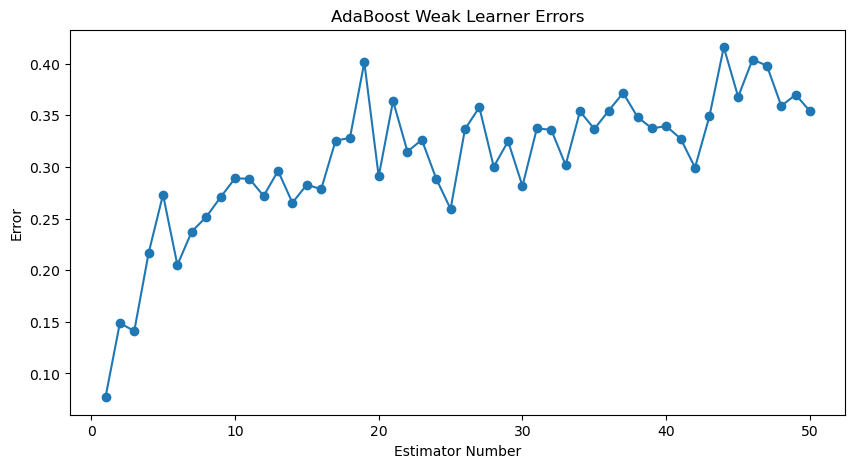

In [52]:
# Visualize estimator errors
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(ada.estimator_errors_) + 1),
    ada.estimator_errors_,
    marker="o"
)

plt.xlabel("Estimator Number")
plt.ylabel("Error")
plt.title("AdaBoost Weak Learner Errors")

plt.show()

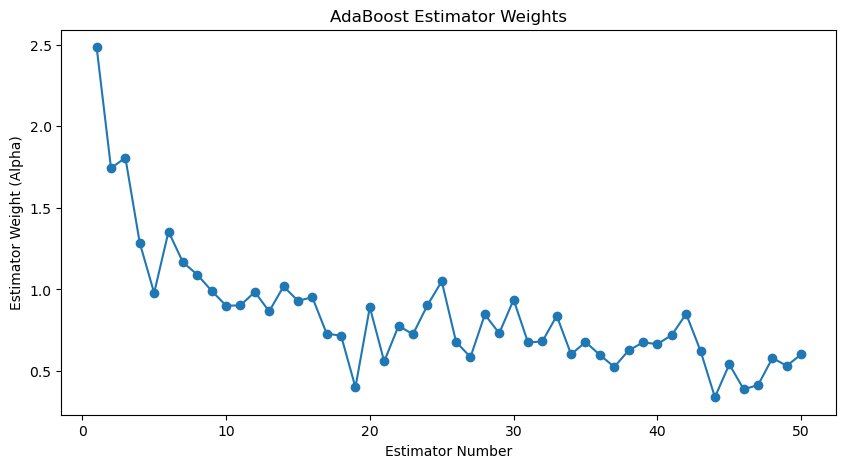

In [53]:
# Visualise the estimator weights

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(ada.estimator_weights_) + 1),
    ada.estimator_weights_,
    marker="o"
)

plt.xlabel("Estimator Number")
plt.ylabel("Estimator Weight (Alpha)")
plt.title("AdaBoost Estimator Weights")

plt.show()